In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [6]:
DATA_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\train_ugly"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print(train_ds.class_names)

Found 10000 files belonging to 5 classes.
Using 8000 files for training.
Using 8000 files for training.
Found 10000 files belonging to 5 classes.
Using 2000 files for validation.
['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [3]:
CLEAN_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_clean"

clean_test_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(clean_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(clean_test_ds).numpy())

Found 2499 files belonging to 5 classes.
['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Test batches: 79


In [4]:
UGLY_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_ugly"

ugly_test_ds = tf.keras.utils.image_dataset_from_directory(
    UGLY_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(ugly_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(ugly_test_ds).numpy())

Found 2499 files belonging to 5 classes.
['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Test batches: 79
['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Test batches: 79


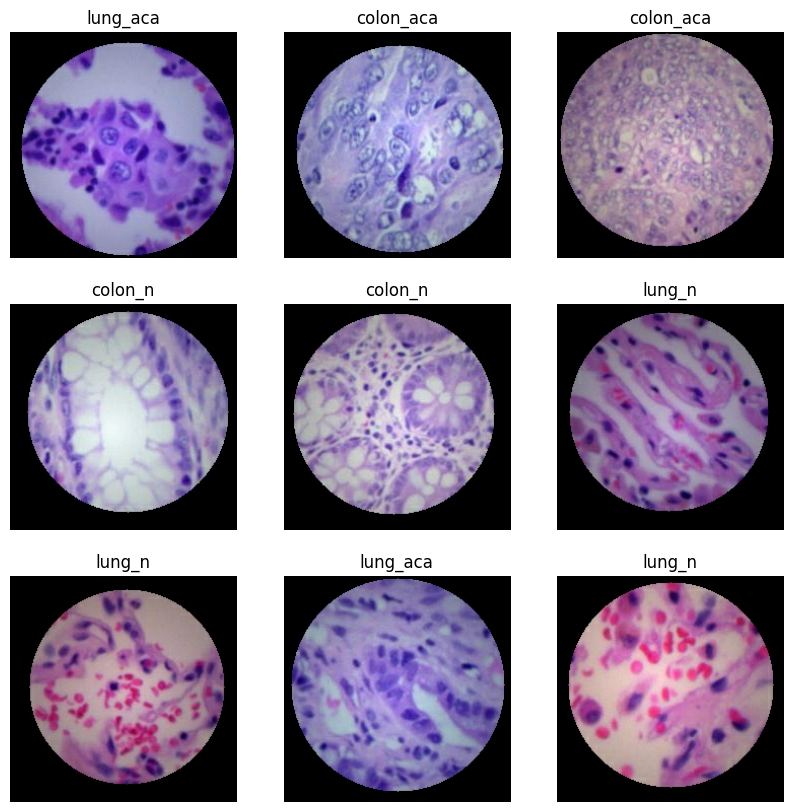

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [7]:
base_model.trainable = False

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(5, activation="softmax")
])

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.3187 - loss: 1.6128 - val_accuracy: 0.7455 - val_loss: 0.7879
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.7453 - loss: 0.7365 - val_accuracy: 0.8285 - val_loss: 0.5333
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.8316 - loss: 0.5145 - val_accuracy: 0.8535 - val_loss: 0.4323
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.8621 - loss: 0.4311 - val_accuracy: 0.8575 - val_loss: 0.3937
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.8849 - loss: 0.3716 - val_accuracy: 0.8625 - val_loss: 0.3661


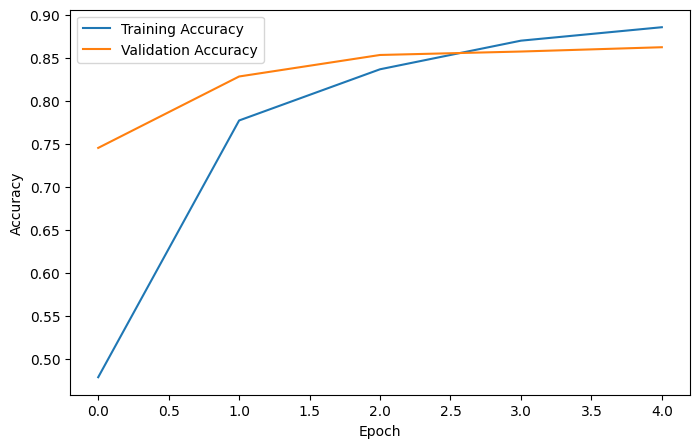

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

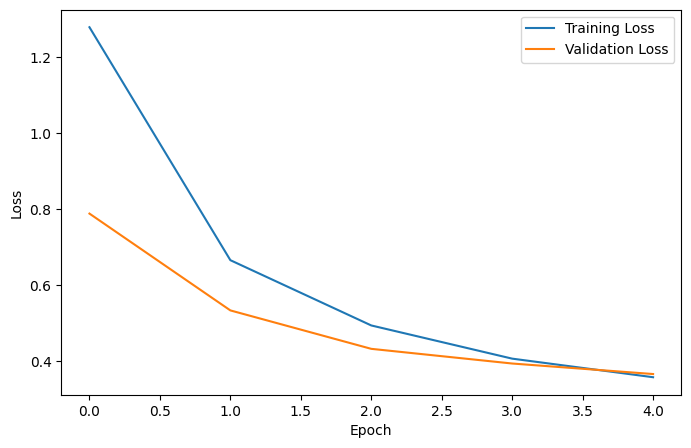

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
model.save(r"C:\Users\arif.arshad\Desktop\MicroAI\models\ugly_micro_ai.keras")

In [15]:
y_true = []
y_pred = []

for images, labels in clean_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = clean_test_ds.class_names

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.8806    0.3540    0.5050       500
     colon_n     0.4416    0.9980    0.6123       500
    lung_aca     0.7959    0.4680    0.5894       500
      lung_n     0.8143    1.0000    0.8977       500
    lung_scc     0.8231    0.4289    0.5639       499

    accuracy                         0.6499      2499
   macro avg     0.7511    0.6498    0.6336      2499
weighted avg     0.7511    0.6499    0.6337      2499



In [16]:
y_true_ugly = []
y_pred_ugly = []

for images, labels in ugly_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true_ugly.extend(labels.numpy())
    y_pred_ugly.extend(predicted_labels)

y_true_ugly = np.array(y_true_ugly)
y_pred_ugly = np.array(y_pred_ugly)

print(
    classification_report(
        y_true_ugly,
        y_pred_ugly,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.9278    0.8220    0.8717       500
     colon_n     0.9360    0.9660    0.9508       500
    lung_aca     0.8896    0.5960    0.7138       500
      lung_n     0.9802    0.9880    0.9841       500
    lung_scc     0.6805    0.9559    0.7950       499

    accuracy                         0.8655      2499
   macro avg     0.8828    0.8656    0.8631      2499
weighted avg     0.8829    0.8655    0.8631      2499



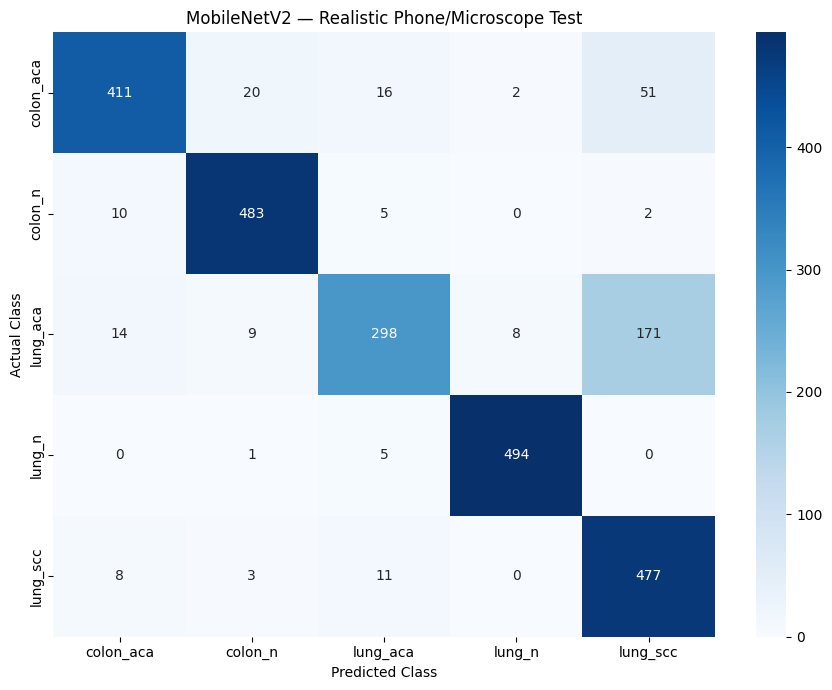

In [17]:
cm_ugly = confusion_matrix(
    y_true_ugly,
    y_pred_ugly
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_ugly,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 — Realistic Phone/Microscope Test")

plt.tight_layout()
plt.show()